# Report Visualisations

In [3]:
import sys
import pathlib
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Add src/ to path so data_loaders is importable
ROOT = pathlib.Path.cwd().parent   # notebooks/ -> project root
sys.path.insert(0, str(ROOT / "src"))

from data_loaders import load_cpih_monthly, load_cpih_fy_indices, load_lcf_shares

OUTPUT = ROOT / "data" / "output"
%matplotlib inline

In [6]:
plt.rcParams.update({
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "serif",
    "font.size":         9,
    "axes.titlesize":    11,
    "figure.dpi":        150,
})

TENURE_4 = ["social_rent", "private_rent", "own_outright", "own_mortgage"]

TENURE_LABELS = {
    "social_rent":  "Social Rent",
    "private_rent": "Private Rent",
    "own_outright": "Own Outright",
    "own_mortgage": "Own Mortgage",
}

TENURE_COLOURS = {
    "social_rent":  "#1b9e77",
    "private_rent": "#d95f02",
    "own_outright": "#7570b3",
    "own_mortgage": "#e7298a",
}

COICOP_MAP = {
    "share_01_food_non_alcoholic":  "Food",
    "share_02_alcohol_tobacco":     "Alcohol & Tobacco",
    "share_03_clothing_footwear":   "Clothing",
    "share_04_housing_fuel_power":  "Housing & Utilities",
    "share_05_furnishings":         "Furnishings",
    "share_06_health":              "Health",
    "share_07_transport":           "Transport",
    "share_08_communication":       "Communication",
    "share_09_recreation_culture":  "Recreation",
    "share_10_education":           "Education",
    "share_11_restaurants_hotels":  "Restaurants",
    "share_12_misc_goods_services": "Misc. Goods",
}

OFFICIAL_COICOP = list(COICOP_MAP.keys())

In [10]:
shares = load_lcf_shares()
monthly = load_cpih_monthly()
fy_index = load_cpih_fy_indices()

# archetype_name, archetype_value, year, inflation_rate
group_inflation = pd.read_csv(OUTPUT / "group_inflation_rates.csv")

# archetype name, archetype value, year, COICOP label, contribution
coicop_contributions = pd.read_csv(OUTPUT / "inflation_decomposition.csv")

print("These are the shapes of each database (for debugging):")
print(f"- LCF shares: {shares.shape}")
print(f"- CPIH monthly: {monthly.shape}")
print(f"- CPIH FY index: {fy_index.shape}")
print(f"- Inflation: {group_inflation.shape}")
print(f"- Decomposition: {coicop_contributions.shape}")

These are the shapes of each database (for debugging):
- LCF shares: (45500, 25)
- CPIH monthly: (458, 20)
- CPIH FY index: (9, 17)
- Inflation: (135, 4)
- Decomposition: (1890, 5)


#### Figure 2: Data quality audit
- (a) How much data is genuinely missing per column?
- (b) How many households report 0 spending per COICOP division? This is not a data quality issue but reflects that LCF is a biweekly diary where households may have reasons for 0 spending in a category (most households don't pay for education or tobacco every 2 weeks).

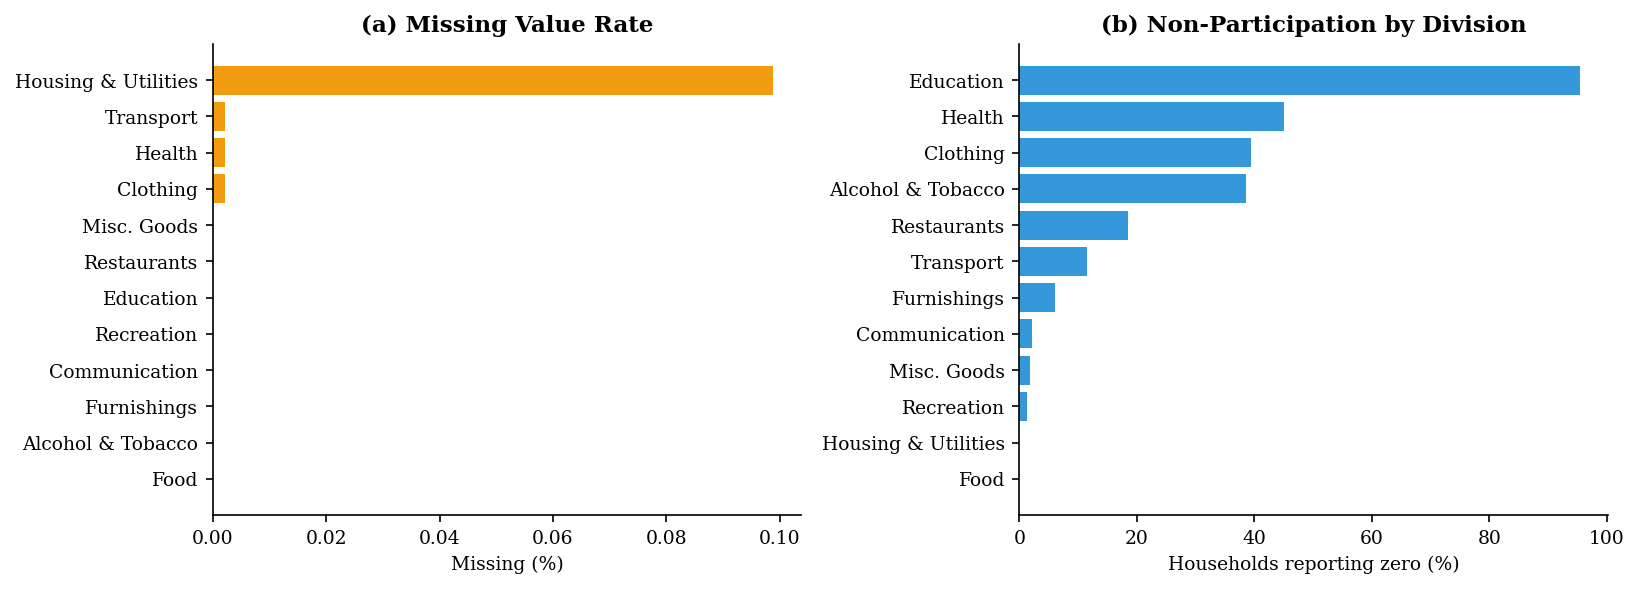

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Missing value rate for each COICOP division
missing_rates = (shares[share_cols].isnull().sum() / len(shares) * 100).sort_values()
missing_values_labels = [COICOP_MAP.get(c, c) for c in missing_rates.index]
colours = ["#E74C3C" if v > 1 else "#F39C12" if v > 0 else "#27AE60" for v in missing_rates.values]
ax1.barh(missing_values_labels, missing_rates.values, color=colours)
ax1.set_xlabel("Missing (%)")
ax1.set_title("(a) Missing Value Rate", weight="bold")

# (b) Non-participation for each COICOP division
zero_pct = ((shares[share_cols] == 0).sum() / len(shares) * 100).sort_values()
zero_labels = [COICOP_MAP.get(c, c) for c in zero_pct.index]
ax2.barh(zero_labels, zero_pct.values, color="#3498DB")
ax2.set_xlabel("Households reporting zero (%)")
ax2.set_title("(b) Non-Participation by Division", weight="bold")

plt.tight_layout()
plt.show()


Fig. 2 audits data completeness and expenditure prevalence across the 12 COICOP divisions. Panel (a) confirms that missingness is negligible: only Housing & Utilities exhibits any missing values (0.10%), with all other divisions at or below 0.01%. This reflects the structured diary design of the LCF where households record expenditure against pre-defined COICOP categories.

Panel (b) reveals a structurally different pattern. Education (95.5%), Health (45.1%), and Clothing (39.4%) show high rates of zero-expenditure, but these are not data quality failures — they reflect genuine non-purchase during the two-week diary window. For instance, most households do not pay private school tuition fees, buy clothing and tobacco every fortnight. However, Food (0.04%) and Housing and Utilties (0.2%) are near universal, reflecting all households eat and pay for shelter. Zero food expense or housing likely represent incomplete diaries so they are removed during filtering (296 for food, 50 for housing), alongside 7 households with negative total expenditure. In total, 350 households (0.76% of the sample) are removed.

"""""This pattern motivates the choice of domain-based filtering over per-column winsorisation. For zero-heavy categories such as Education, the IQR collapses and would incorrectly flag legitimate non-spenders as outliers. Moreover, expenditure shares are compositional — they sum to 1.0 per household — so clipping any individual share breaks the budget constraint. Group averaging over 500+ households per tenure cell provides natural robustness to individual-level variation."""""

#### Figure 3, Distribution of COICOP Expenditure Shares
- (a) Boxplots showing the spread of each COICOP share across all households
- (b) Skewness and Kurtosis per share.


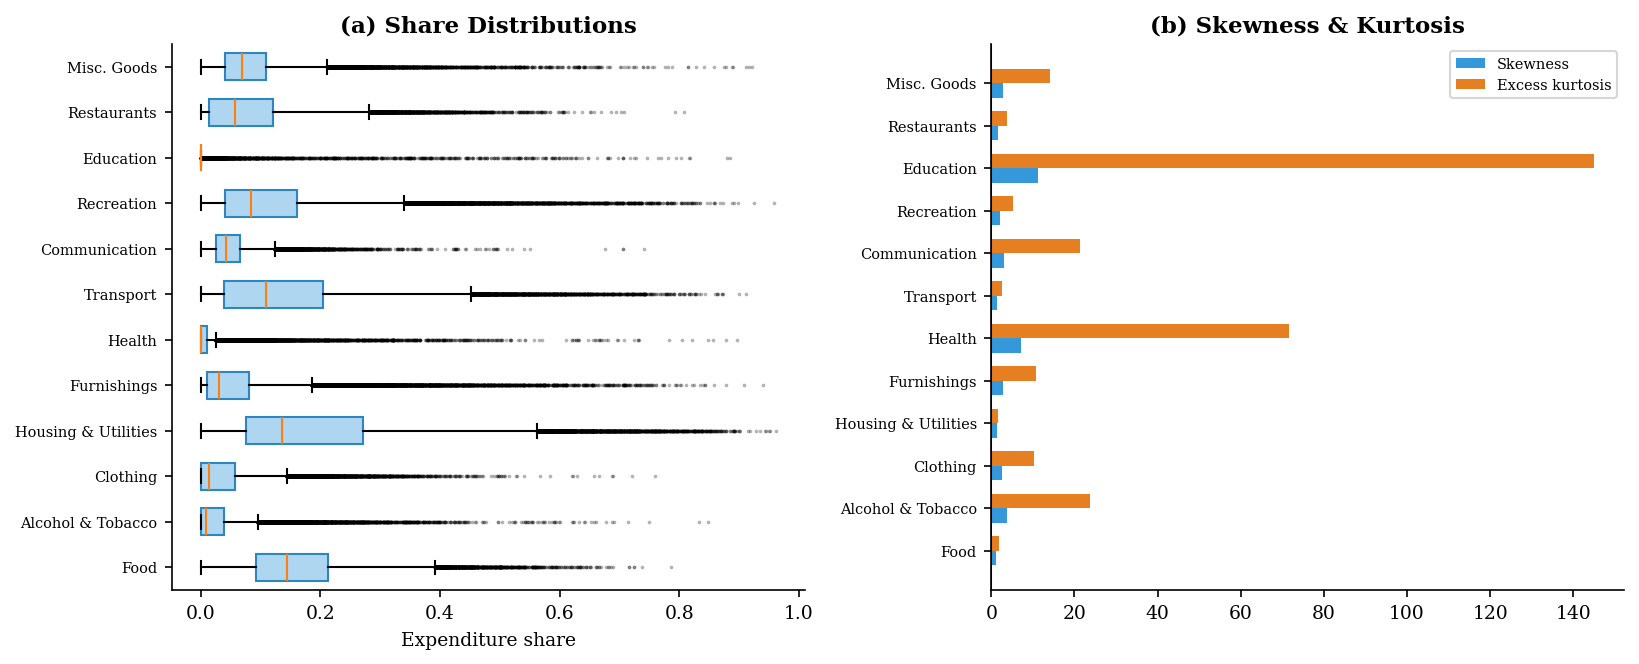

In [14]:
share_data = shares[share_cols].dropna()
short = [COICOP_MAP.get(c, c) for c in share_cols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# LHS: Boxplots
bp = ax1.boxplot([share_data[c].values for c in share_cols],
                 vert=False, patch_artist=True, widths=0.6,
                 flierprops=dict(marker=".", markersize=1.5, alpha=0.3))
for patch in bp["boxes"]:
    patch.set_facecolor("#AED6F1")
    patch.set_edgecolor("#2E86C1")
ax1.set_yticklabels(short, fontsize=7)
ax1.set_xlabel("Expenditure share")
ax1.set_title("(a) Share Distributions", weight="bold")

# RHS: Skewness & kurtosis
skew = [share_data[c].skew() for c in share_cols]
kurt = [share_data[c].kurtosis() for c in share_cols]
y = np.arange(len(share_cols))
ax2.barh(y - 0.17, skew, height=0.34, color="#3498DB", label="Skewness")
ax2.barh(y + 0.17, kurt, height=0.34, color="#E67E22", label="Excess kurtosis")
ax2.set_yticks(y)
ax2.set_yticklabels(short, fontsize=7)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.legend(fontsize=7)
ax2.set_title("(b) Skewness & Kurtosis", weight="bold")

plt.tight_layout()
plt.show()



(A) reveals considerable variation in spread of expenditure shares across COICOP divisions across all 45,500 households. Food and Housing & Utilities show the highest median shares - consistent with being essential spending categories. In contrast, Education and Health are concentrated near 0% with a long right tail: some households allocate upwards of 10% of expenditure to Education. Public school and the NHS are widely used with a minority of households using private school or healthcare. Housing & Utilities show the widest IQR, highlighting the structural divide between renters and outright owners.

(B) further explains this asymmetry. Education, Health and Alcohol and Tobacco are most skewed (>2), confirming the long right tails in the boxplots. These categories show elevated excess kurtosis, indicating extreme values are more common than a normal distribution would predict. Food and Housing and Utilities are nearly symmetric, as they are universal expenditure categories for almost all households.

Households were only removed if they had zero spending on essential categories (categories where zero spending is implausible) or negative total spending, as this reflects an incomplete expenditure diary. 296 with zero food expenditure, 50 with zero housing expenditure and 7 with negative total spending were removed. The heavily right-skewed distributions in categories like Education and Health are not outliers; they reflect genuine spending heterogeneity among households. Z-score filtering was considered but is unsuitable: with Education's mean near zero and 95.5% of households reporting no spending, any household paying tuition fees would be flagged as extreme despite representing a legitimate subpopulation. Winsorisation was also considered but is incompatible with compositional data: expenditure shares must sum to 1.0 per household, and capping one share breaks this constraint. Redistributing the clipped amount across the remaining categories would require an arbitrary allocation rule that distorts the Laspeyres weights.

In [ ]:
'''
References:
- 6-7% of pupils attend private schools in the UK:
https://ifs.org.uk/publications/tax-private-school-fees-and-state-school-spending
- 
'''

#### Table II: Summary Statistics by Tenure

Weighted means of key expenditure shares and income, disaggregated by tenure group.
Shows the structural differences in household budgets that drive differential inflation.

In [18]:
def compute_weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

tenure_groups = [("All households", shares)]
for tenure in TENURE_4:
    tenure_groups.append((TENURE_LABELS[tenure], shares[shares["tenure_type"] == tenure]))

rows = []
for group_name, group_data in tenure_groups:
    household_weights = group_data["household_weight"] if "household_weight" in group_data else pd.Series(1.0, index=group_data.index)

    row = {"Group": group_name, "N": f"{len(group_data):,}"}
    row["Food %"]       = f"{compute_weighted_mean(group_data['share_01_food_non_alcoholic'], household_weights) * 100:.1f}"
    row["Energy %"]     = f"{compute_weighted_mean(group_data['share_04_energy_other'], household_weights) * 100:.1f}"
    row["Rent %"]       = f"{compute_weighted_mean(group_data['share_04_actual_rent'], household_weights) * 100:.1f}"
    row["Transport %"]  = f"{compute_weighted_mean(group_data['share_07_transport'], household_weights) * 100:.1f}"
    row["Recreation %"] = f"{compute_weighted_mean(group_data['share_09_recreation_culture'], household_weights) * 100:.1f}"
    
    if "hh_income_gross_weekly" in group_data:
        row["Gross £/wk"] = f"{compute_weighted_mean(group_data['hh_income_gross_weekly'], household_weights):.0f}"
    
    rows.append(row)

summary_table = pd.DataFrame(rows)
summary_table



,Group,N,Food %,Energy %,Rent %,Transport %,Recreation %
0,All households,"45,500",16.0,12.9,8.6,13.7,11.9
1,Social Rent,"6,442",18.4,15.2,18.0,8.6,9.0
2,Private Rent,"6,763",12.4,9.9,32.2,10.6,7.4
3,Own Outright,"14,001",15.2,11.1,0.0,18.1,13.5
4,Own Mortgage,"17,874",17.3,14.9,0.3,13.6,14.0


#### Figure 4: Tenure Basket Deviation from Pooled Mean
- Heatmap showing how each tenure group's spending deviates from the overall average.
- Bold values = deviation in percentage points, parentheses = raw share.
- This is the central EDA figure — it shows *where* tenure groups differ, not just *that* they differ.

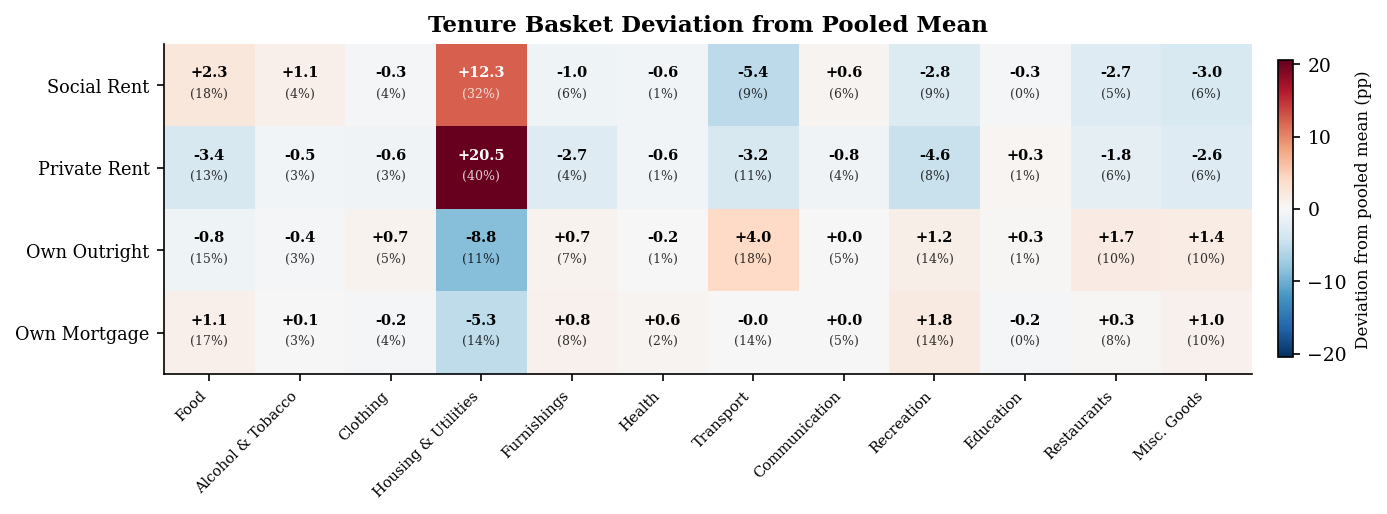

In [35]:
sub = shares[shares["tenure_type"].isin(TENURE_4)]

# Pooled mean across all tenure groups
pooled_mean = sub[share_cols].mean()

# Mean per tenure group
tenure_means = sub.groupby("tenure_type")[share_cols].mean()
tenure_means = tenure_means.loc[TENURE_4]  # enforce row order

# Deviation in percentage points
deviation = (tenure_means - pooled_mean) * 100
raw_pct = tenure_means * 100

# Each row is a tenure type, each column is a COICOP division.
row_labels = [TENURE_LABELS[t] for t in tenure_means.index]
col_labels = [COICOP_MAP[c] for c in share_cols]

fig, ax = plt.subplots(figsize=(10, 3.5))
colour_scale_max = max(np.abs(deviation.values).max(), 1.0)
im = ax.imshow(deviation.values, cmap="RdBu_r", vmin=-colour_scale_max, vmax=colour_scale_max, aspect="auto")

# Annotate each cell: bold deviation + raw share underneath
for i in range(deviation.shape[0]):
    for j in range(deviation.shape[1]):
        dev = deviation.values[i, j]
        raw = raw_pct.values[i, j]

        # Use white text if it gets dark
        colour = "white" if abs(dev) > colour_scale_max * 0.55 else "black"
        ax.text(j, i - 0.15, f"{dev:+.1f}", ha="center", va="center", fontsize=7, color=colour, weight="bold")
        ax.text(j, i + 0.1, f"({raw:.0f}%)", ha="center", va="center", fontsize=6, color=colour, alpha=0.8)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=8.5)
cbar = fig.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Deviation from pooled mean (pp)", fontsize=8)

ax.set_title("Tenure Basket Deviation from Pooled Mean", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()


#### Figure 6: CPIH Sub-Index Time Series with Key Events

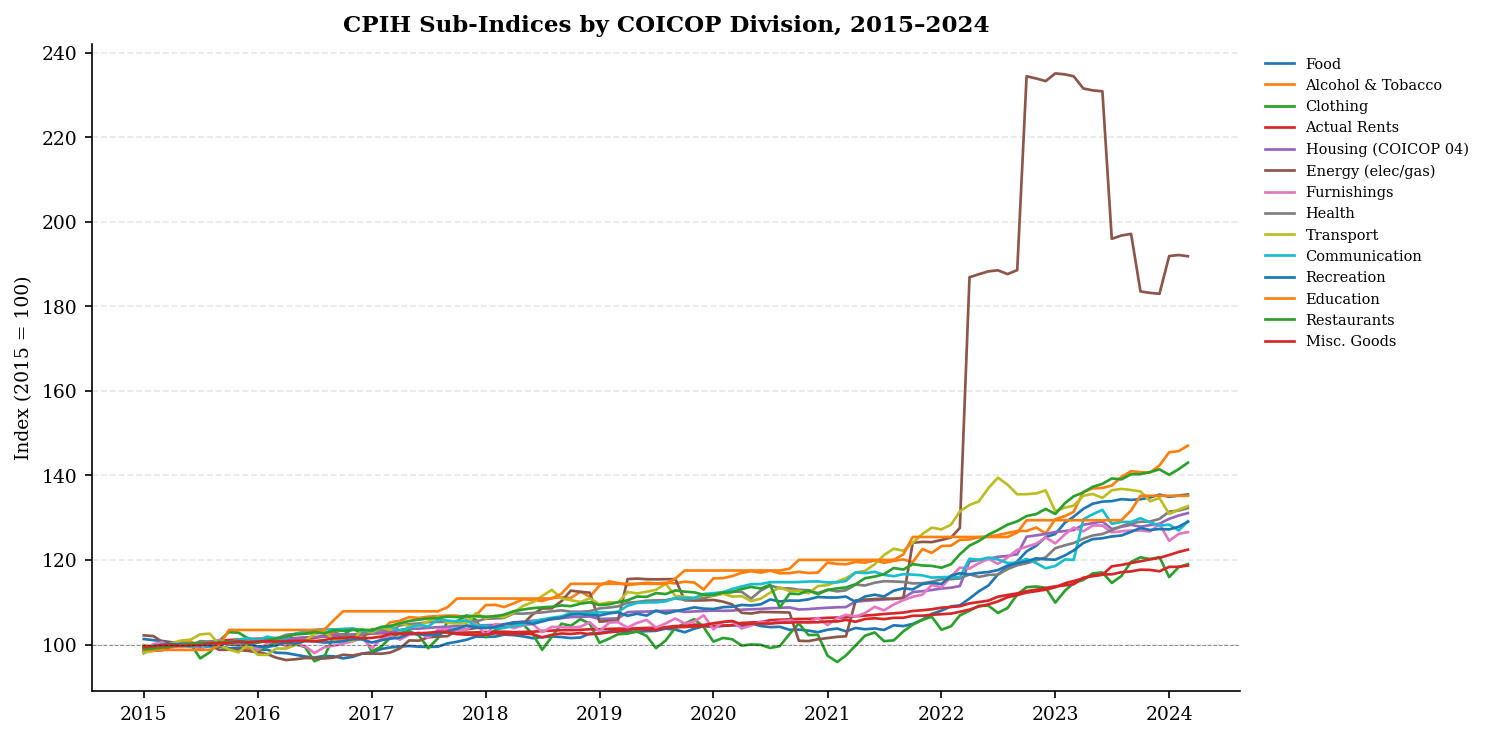

In [53]:
PRICE_MAP = {
    "food_non_alcoholic":    "Food",
    "alcohol_tobacco":       "Alcohol & Tobacco",
    "clothing_footwear":     "Clothing",
    "actual_rents":          "Actual Rents",
    "non_rent_housing_fuel": "Home Energy",
    "housing_fuel_power":    "Housing (COICOP 04)",
    "electricity_gas_fuels": "Energy (elec/gas)",
    "furnishings":           "Furnishings",
    "health":                "Health",
    "transport":             "Transport",
    "communication":         "Communication",
    "recreation_culture":    "Recreation",
    "education":             "Education",
    "restaurants_hotels":    "Restaurants",
    "misc_goods_services":   "Misc. Goods",
}
OFFICIAL_PRICE_NAMES = list(PRICE_MAP.keys())

price_cols = [c for c in OFFICIAL_PRICE_NAMES if c in monthly.columns]
sorted_monthly = monthly[(monthly["date"] >= "2015-01-01") & (monthly["date"] <= "2024-03-01")].sort_values("date")
fig, ax = plt.subplots(figsize=(10, 5))

for col in price_cols:
    label = PRICE_MAP.get(col, col)
    ax.plot(sorted_monthly["date"], sorted_monthly[col], linewidth=1.3, label=label)

ax.axhline(100, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
ax.set_ylabel("Index (2015 = 100)")
ax.set_title("CPIH Sub-Indices by COICOP Division, 2015–2024", fontsize=11, weight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()



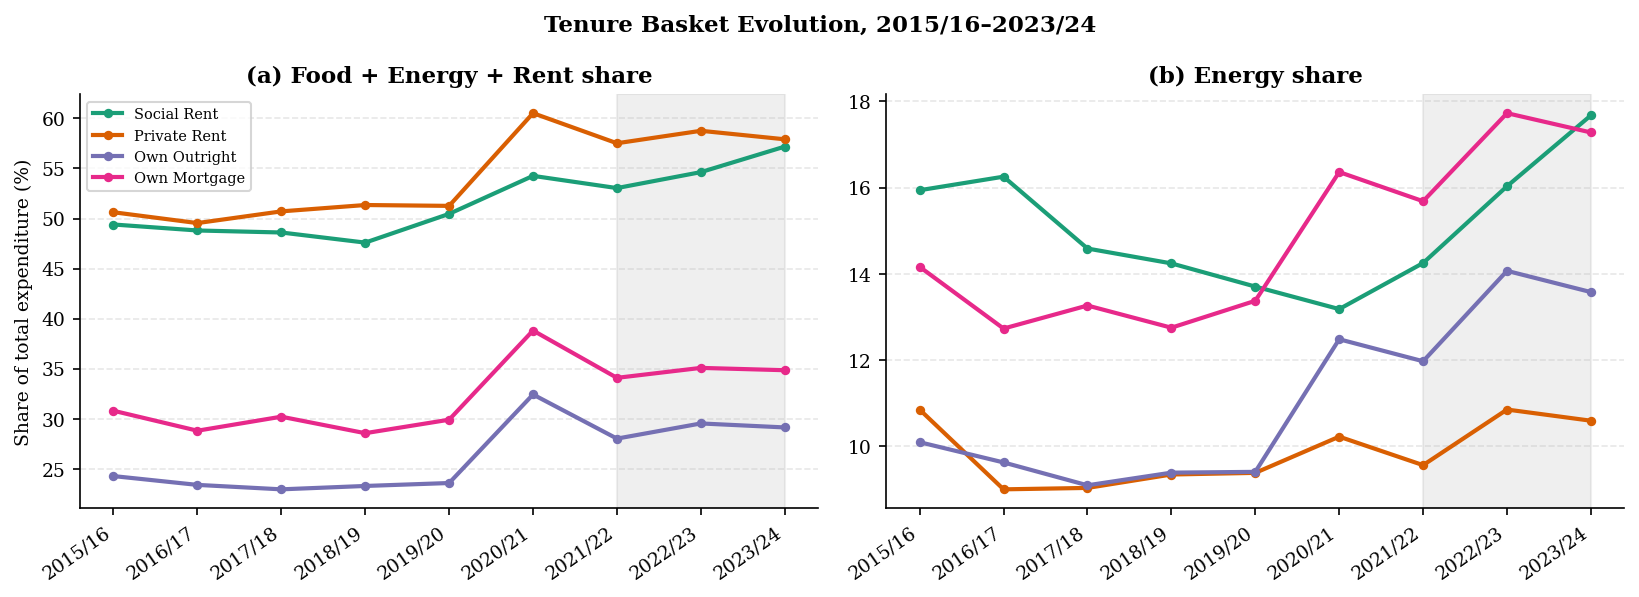

In [55]:
basket_data = shares[shares["tenure_type"].isin(TENURE_4)].copy()
basket_data["essentials"] = (basket_data["share_01_food_non_alcoholic"]
                           + basket_data["share_04_energy_other"]
                           + basket_data["share_04_actual_rent"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

years = sorted(basket_data["year"].unique())

for tenure in TENURE_4:
    tenure_data = basket_data[basket_data["tenure_type"] == tenure]
    
    essentials_by_year = []
    energy_by_year = []
    
    for year in years:
        year_data = tenure_data[tenure_data["year"] == year]
        if "household_weight" in year_data.columns:
            w = year_data["household_weight"].fillna(0)
            essentials_by_year.append(compute_weighted_mean(year_data["essentials"], w) * 100)
            energy_by_year.append(compute_weighted_mean(year_data["share_04_energy_other"], w) * 100)
        else:
            essentials_by_year.append(year_data["essentials"].mean() * 100)
            energy_by_year.append(year_data["share_04_energy_other"].mean() * 100)
    
    ax1.plot([y + 0.5 for y in years], essentials_by_year,
             color=TENURE_COLOURS[tenure], linewidth=2, marker="o",
             markersize=3.5, label=TENURE_LABELS[tenure])
    ax2.plot([y + 0.5 for y in years], energy_by_year,
             color=TENURE_COLOURS[tenure], linewidth=2, marker="o",
             markersize=3.5, label=TENURE_LABELS[tenure])

for ax in [ax1, ax2]:
    ax.axvspan(2021.5, 2023.5, color="grey", alpha=0.12)
    ax.set_xticks([y + 0.5 for y in years])
    ax.set_xticklabels([f"{y}/{str(y+1)[-2:]}" for y in years], rotation=35, ha="right")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

ax1.set_ylabel("Share of total expenditure (%)")
ax1.set_title("(a) Food + Energy + Rent share", weight="bold")
ax1.legend(fontsize=7)

ax2.set_title("(b) Energy share", weight="bold")

fig.suptitle("Tenure Basket Evolution, 2015/16–2023/24", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()



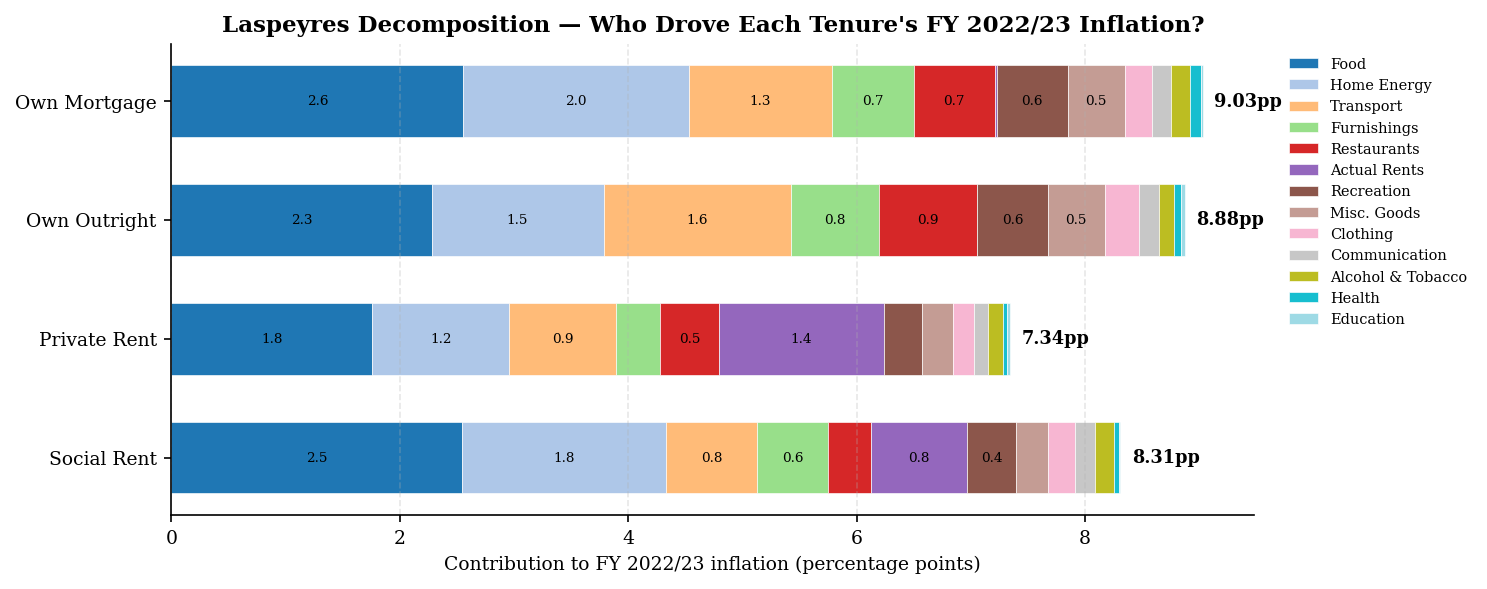

In [56]:
# Filter to tenure groups, crisis year, exclude the all_items summary row
crisis_decomp = coicop_contributions[
    (coicop_contributions["archetype_name"] == "tenure_type") &
    (coicop_contributions["year"] == 2022) &
    (coicop_contributions["coicop_label"] != "all_items")
].copy()

# Pivot to tenure x COICOP matrix
pivot = crisis_decomp.pivot_table(
    index="archetype_value",
    columns="coicop_label",
    values="contribution",
    aggfunc="first"
).fillna(0)

pivot = pivot.loc[[t for t in TENURE_4 if t in pivot.index]]

# Order columns by average contribution (biggest first)
col_order = pivot.mean().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 4))

row_labels = [TENURE_LABELS[t] for t in pivot.index]
y = np.arange(len(row_labels))
left = np.zeros(len(row_labels))

cmap = plt.get_cmap("tab20", len(col_order))

for i, col in enumerate(col_order):
    values = pivot[col].to_numpy()
    label = PRICE_MAP.get(col, col)
    ax.barh(y, values, left=left, height=0.6,
            color=cmap(i), edgecolor="white", linewidth=0.3, label=label)
    # Label segments larger than 0.4pp
    for j, v in enumerate(values):
        if v > 0.4:
            ax.text(left[j] + v / 2, j, f"{v:.1f}",
                    ha="center", va="center", fontsize=6.5)
    left += values

# Total inflation label at end of each bar
totals = pivot.sum(axis=1).to_numpy()
for i, total in enumerate(totals):
    ax.text(total + 0.1, i, f"{total:.2f}pp",
            va="center", fontsize=8.5, weight="bold")

ax.set_yticks(y)
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_xlabel("Contribution to FY 2022/23 inflation (percentage points)")
ax.set_title("Laspeyres Decomposition — Who Drove Each Tenure's FY 2022/23 Inflation?",
             fontsize=11, weight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)
plt.tight_layout()
plt.show()
